# Bach and Tchaikovsky Harmonic Analysis


The source data contains 639 Bach compositions and 94 Tchaikovsky compositions.

## Questions to answers
1. Are there differences in the harmonic vocabularies between the two composers? (look at differences in pitch class frequency)
2. Does Tchaikovsky have a larger harmonic vocabulary than Bach? (variance in pitch-class within each piece)
3. Is there more chromaticism (this is a distinctive of romantic era music, defined as pitches a semitone apart) in Tchaikovsky than in Bach?
4. What keys does each composer prefer to compose in?
5. Does the genre of music differ by composer?

## Setup and data preparation

In [30]:
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

bach_path = "BachSlices.csv"
tchaikovsky_path = "TchaikovskySlices.csv"

bach = pd.read_csv(bach_path)
tchaikovsky = pd.read_csv(tchaikovsky_path)

print(bach.head().to_string())
bach["composer"] = "Bach"
tchaikovsky["composer"] = "Tchaikovsky"
df = pd.concat([bach, tchaikovsky], ignore_index=True)

def parse_normal_form(x):
    return tuple(ast.literal_eval(x))

df["normal_form"] = df["NormalForm"].apply(parse_normal_form)

piece_stats = (
    df.groupby(["composer", "file"])
      .agg(
          harmonicVocabulary=("normal_form", "nunique"),
          events=("normal_form", "size"),
          avgSonoritySize=("normal_form", lambda x: np.mean([len(v) for v in x])),
          chromaticRate=("normal_form", lambda x: np.mean([
              any(((b - a) % 12 in (1, 11)) for i, a in enumerate(v) for b in v[i+1:])
              for v in x
          ]))
      )
      .reset_index()
)

def entropy(values):
    counts = pd.Series(values).value_counts(normalize=True)
    return -(counts * np.log2(counts)).sum()

entropy_df = (
    df.groupby(["composer", "file"])["normal_form"]
      .apply(entropy)
      .reset_index(name="harmonicEntropy")
)

piece_stats = piece_stats.merge(entropy_df, on=["composer", "file"])

   offset                              Chord NormalForm PCsInNormalForm GlobalScaleDegrees  HighestPitch  LowestPitch                                     file Composer LocalTonic LocalMode LocalSDForm_BassSD  Confidence
0    0.00           <music21.chord.Chord A4>        [0]             [9]                [0]            69           69  English Suite No 2 courante A minor.mid     Bach          9     minor              [0]_0     0.90313
1    0.50  <music21.chord.Chord C4 E4 A4 A3>  [0, 3, 7]       [9, 0, 4]          [0, 3, 7]            69           57  English Suite No 2 courante A minor.mid     Bach          9     minor        [0, 3, 7]_0     0.90313
2    1.25     <music21.chord.Chord C4 E4 A4>  [0, 3, 7]       [9, 0, 4]          [0, 3, 7]            69           60  English Suite No 2 courante A minor.mid     Bach          9     minor        [0, 3, 7]_3     0.90313
3    1.50  <music21.chord.Chord C4 E4 A4 E3>  [0, 3, 7]       [9, 0, 4]          [0, 3, 7]            69           52  E

## Plot 1: Harmonic vocabulary entropy

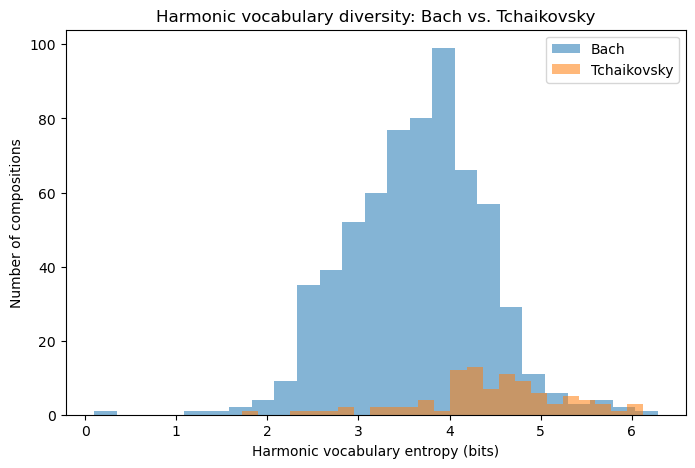

In [16]:
plt.figure(figsize=(8, 5))
for composer in ["Bach", "Tchaikovsky"]:
    vals = piece_stats.loc[piece_stats["composer"] == composer, "harmonicEntropy"]
    plt.hist(vals, bins=25, alpha=0.55, label=composer, density=False)
plt.xlabel("Harmonic vocabulary entropy (bits)")
plt.ylabel("Number of compositions")
plt.title("Harmonic vocabulary diversity: Bach vs. Tchaikovsky")
plt.legend()
plt.savefig("bach_tchaikovsky_harmonic_entropy.png")
# plt.show()

## Plot 2: Harmonic vocabulary size

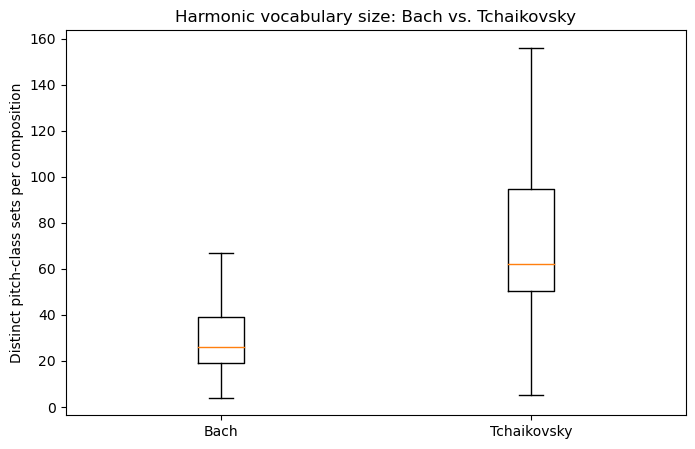

In [17]:
plt.figure(figsize=(8, 5))
data = [
    piece_stats.loc[piece_stats["composer"] == "Bach", "harmonicVocabulary"],
    piece_stats.loc[piece_stats["composer"] == "Tchaikovsky", "harmonicVocabulary"]
]
plt.boxplot(data, labels=["Bach", "Tchaikovsky"], showfliers=False)
plt.ylabel("Distinct pitch-class sets per composition")
plt.title("Harmonic vocabulary size: Bach vs. Tchaikovsky")
plt.savefig("bach_tchaikovsky_harmonic_vocabulary.png")
# plt.show()

## Plot 3: Distinctive sonorities

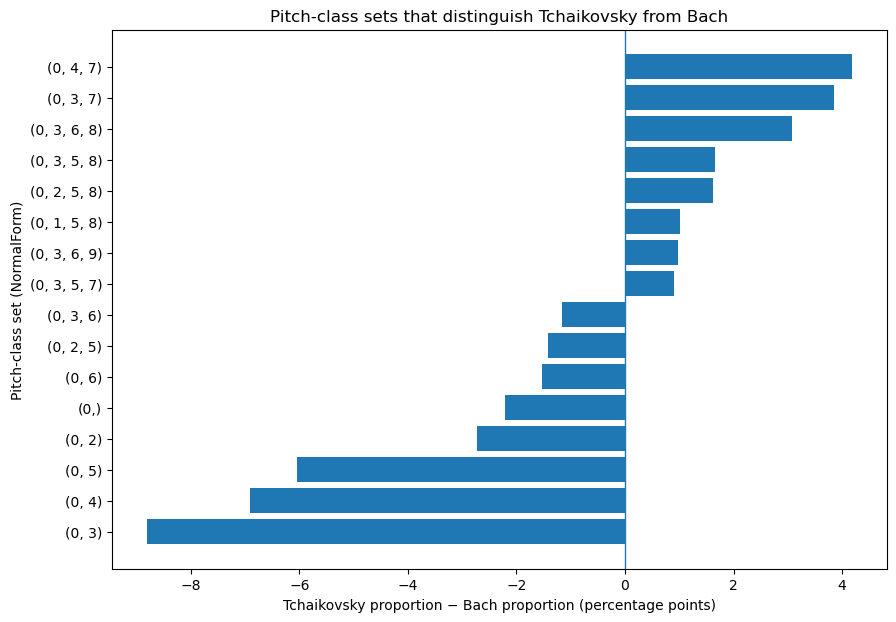

In [18]:
counts = df.groupby(["composer", "normal_form"]).size()
freq = (counts / counts.groupby(level="composer").transform("sum")).rename("proportion").reset_index()

wide = freq.pivot(index="normal_form", columns="composer", values="proportion").fillna(0)
wide["difference"] = wide.get("Tchaikovsky", 0) - wide.get("Bach", 0)

top = pd.concat([
    wide.nlargest(8, "difference"),
    wide.nsmallest(8, "difference")
]).sort_values("difference")

labels = [str(x) for x in top.index]
plt.figure(figsize=(10, 7))
plt.barh(labels, top["difference"] * 100)
plt.axvline(0, linewidth=1)
plt.xlabel("Tchaikovsky proportion − Bach proportion (percentage points)")
plt.ylabel("Pitch-class set (NormalForm)")
plt.title("Pitch-class sets that distinguish Tchaikovsky from Bach")
plt.savefig("bach_tchaikovsky_distinctive_sonorities.png")
# plt.show()

## Plot 4: Chromatic sonority rate

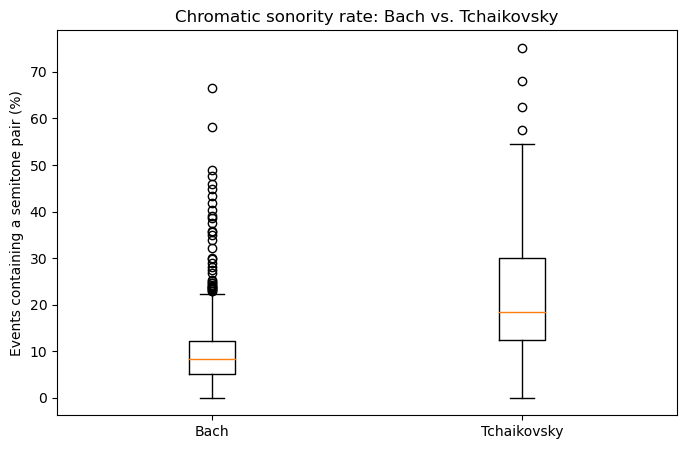

In [19]:
plt.figure(figsize=(8, 5))
data = [
    piece_stats.loc[piece_stats["composer"] == "Bach", "chromaticRate"] * 100,
    piece_stats.loc[piece_stats["composer"] == "Tchaikovsky", "chromaticRate"] * 100
]
plt.boxplot(data, labels=["Bach", "Tchaikovsky"], showfliers=True)
plt.ylabel("Events containing a semitone pair (%)")
plt.title("Chromatic sonority rate: Bach vs. Tchaikovsky")
plt.savefig("bach_tchaikovsky_chromatic_rate.png")
# plt.show()

## Summary statistics

In [20]:
print("\nPiece counts:")
print(piece_stats.groupby("composer").size())
print("\nMedians:")
print(piece_stats.groupby("composer")[["harmonicVocabulary", "harmonicEntropy", "chromaticRate", "avgSonoritySize"]].median())

top_bach = (
    piece_stats[piece_stats["composer"] == "Tchaikovsky"]
    .sort_values("chromaticRate", ascending=False)
    .head(10)
)

print(top_bach[["file", "chromaticRate"]])


Piece counts:
composer
Bach           639
Tchaikovsky     94
dtype: int64

Medians:
             harmonicVocabulary  harmonicEntropy  chromaticRate  \
composer                                                          
Bach                       26.0         3.671941       0.083333   
Tchaikovsky                62.0         4.475729       0.184024   

             avgSonoritySize  
composer                      
Bach                2.508178  
Tchaikovsky         3.127708  
                                 file  chromaticRate
683  Swan Lake 20 19 VII Ab Major.mid       0.751844
693       Swan Lake 20 23 G Major.mid       0.680623
712        Swan Lake 20 7 E Major.mid       0.624601
699       Swan Lake 20 29 A Minor.mid       0.575679
706    Swan Lake 20 4 VI Bb Major.mid       0.545623
677     Swan Lake 20 19 I F Major.mid       0.528866
704    Swan Lake 20 4 IV Bb Major.mid       0.527864
713        Swan Lake 20 8 E Major.mid       0.500144
694       Swan Lake 20 24 C Major.mid       0

# Preferred Genre for each composer

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'Chorale'),
  Text(1, 0, 'Cantata'),
  Text(2, 0, 'Fugue'),
  Text(3, 0, 'Prelude'),
  Text(4, 0, 'SoloDanceOneMovement'),
  Text(5, 0, 'Trio'),
  Text(6, 0, 'FantasyAndFugue'),
  Text(7, 0, 'Concerto'),
  Text(8, 0, 'PreludeAndFugue'),
  Text(9, 0, 'Duet'),
  Text(10, 0, 'SoloSuitePartita'),
  Text(11, 0, 'FantasyandFugue'),
  Text(12, 0, 'Fantasy'),
  Text(13, 0, 'Etude'),
  Text(14, 0, 'SoloScherzoOneMovement'),
  Text(15, 0, 'SoloSonata'),
  Text(16, 0, 'ToccataAndFugue'),
  Text(17, 0, 'Toccata'),
  Text(18, 0, 'CharacterPiece'),
  Text(19, 0, 'Overture'),
  Text(20, 0, 'Ballet'),
  Text(21, 0, 'OtherSolo'),
  Text(22, 0, 'StringQuintet'),
  Text(23, 0, 'Motet'),
  Text(24, 0, 'Symphony')])

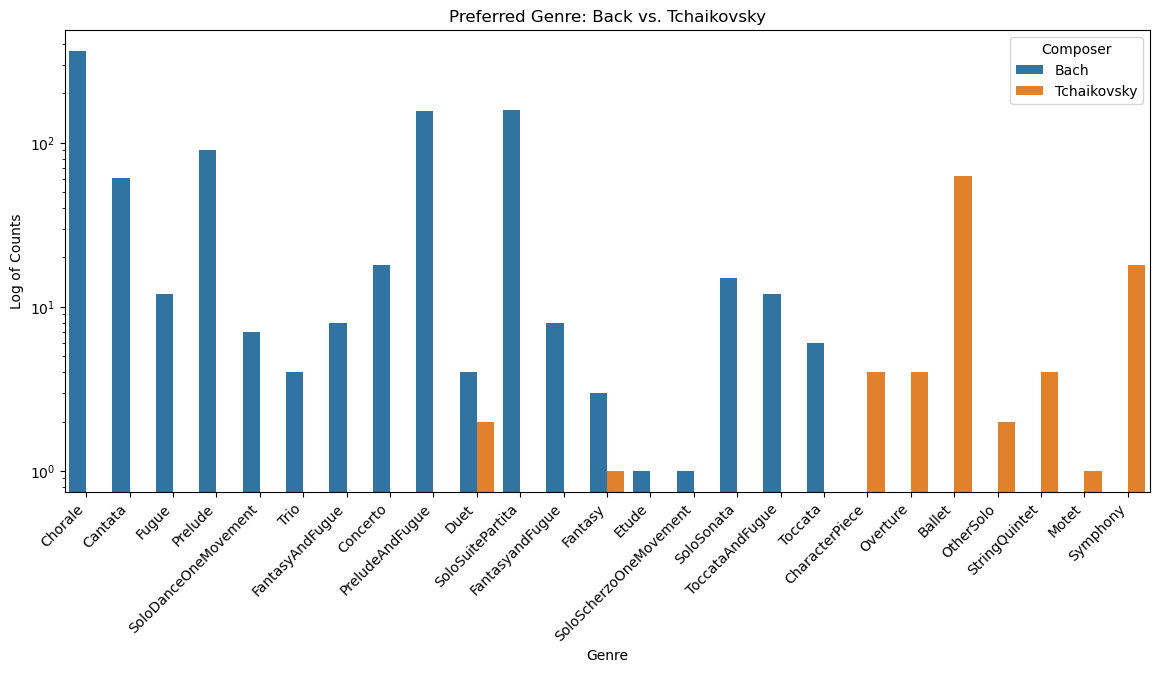

In [46]:


meta_data_df = pd.read_csv('YCAC-metadata2.csv', encoding_errors='ignore')
meta_data_df
plt.figure(figsize=(14,6))
sns.countplot(data=meta_data_df, x='Genre', hue='Composer')
plt.title('Preferred Genre: Back vs. Tchaikovsky')
plt.xlabel('Genre')
plt.ylabel('Log of Counts')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')


# Preferred Keys for Each Composer

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'A major'),
  Text(1, 0, 'D minor'),
  Text(2, 0, 'C major'),
  Text(3, 0, 'Bb major'),
  Text(4, 0, 'A minor'),
  Text(5, 0, 'G minor'),
  Text(6, 0, 'E minor'),
  Text(7, 0, 'D major'),
  Text(8, 0, 'G major'),
  Text(9, 0, 'B minor'),
  Text(10, 0, 'C# minor'),
  Text(11, 0, 'F major'),
  Text(12, 0, 'C minor'),
  Text(13, 0, 'Bb minor'),
  Text(14, 0, 'Ab major'),
  Text(15, 0, 'F# minor'),
  Text(16, 0, 'E major'),
  Text(17, 0, 'Eb major'),
  Text(18, 0, 'F minor'),
  Text(19, 0, 'Undeterminable'),
  Text(20, 0, 'Eb minor'),
  Text(21, 0, 'F# major'),
  Text(22, 0, 'G# minor'),
  Text(23, 0, 'B major'),
  Text(24, 0, 'C# major'),
  Text(25, 0, 'D# minor'),
  Text(26, 0, 'Gb major'),
  Text(27, 0, 'Db major')])

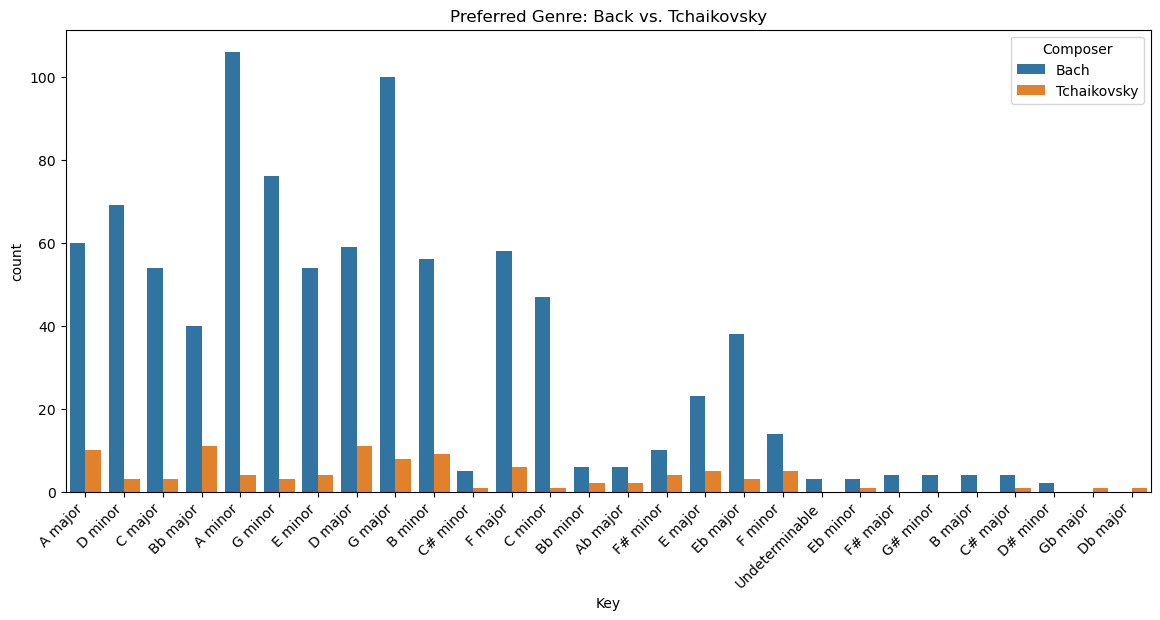

In [ ]:

plt.figure(figsize=(14,6))
sns.countplot(data=meta_data_df, x='Key', hue='Composer')
plt.title('Preferred Genre: Back vs. Tchaikovsky')
plt.xlabel('Key')
# plt.ylabel('Log of Counts')
# plt.yscale('log')
plt.xticks(rotation=45, ha='right')